1. DATA UNDER STANDING

1.1 Import Library

In [1]:
import pandas as pd # digunakan untuk memanipulasi data
import numpy as np # digunakan untuk operasi matematika
import matplotlib.pyplot as plt # digunakan untuk membuat grafik dari data yang kompleks
import seaborn as sns # digunakan untuk membuat grafik dari data yang simple
pd.set_option('display.float_format', lambda x: '%.4f' % x)

1.2 Import Dataset

In [2]:
df = pd.read_csv('Salary.csv')

1.3 Menampilkan 5 Data Teratas

In [ ]:
df.head()

,YearsExperience,Salary
0,0.7000,35010.0000
1,1.2000,37120.0000
2,1.0000,29033.0000
3,1.5000,40510.0000
4,2.1000,45200.0000


1.4 Menampilkan Informasi Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  89 non-null     float64
 1   Salary           89 non-null     float64
dtypes: float64(2)
memory usage: 1.5 KB


1.5 Menampilkan Deskripsi Data

In [5]:
df.describe()

,YearsExperience,Salary
count,89.0000,89.0000
mean,10.1573,132517.0562
std,5.5311,75526.1972
min,0.7000,29033.0000
25%,5.3000,72120.0000
50%,10.0000,120900.0000
75%,14.6000,182900.0000
max,19.9000,518900.0000


1.6 Menampilkan Jumlah Data Kosong

In [6]:
df.isna().sum()

YearsExperience    1
Salary             1
dtype: int64

1.7 Menalpilkan jumblah Duplikasi Data

In [7]:
def cek_duplicate(df):
    duplicated_df = df[df.duplicated(keep= False)]
    index_list = duplicated_df.index.to_list()
    print (f"Kolom yang Terindikasi Duplikat : ")
    print (duplicated_df)
    print (f'Jumblah Duplikasi Data {df.duplicated().sum()}')
    print (f'Baris: {index_list}')

In [8]:
cek_duplicate(df)

Kolom yang Terindikasi Duplikat : 
    YearsExperience      Salary
27           8.3000 103311.0000
28           8.3000 103311.0000
45          13.2000 158991.0000
46          13.2000 158991.0000
Jumblah Duplikasi Data 2
Baris: [27, 28, 45, 46]


2. EKSPLORASI DATA ANALYSIS

2.1 Menampilkan History untuk Melihat Distribusi Data

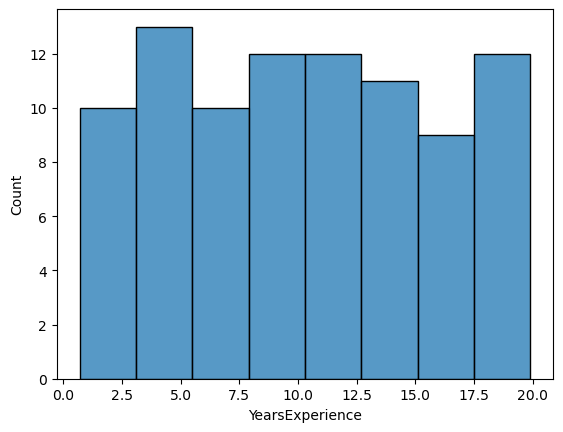

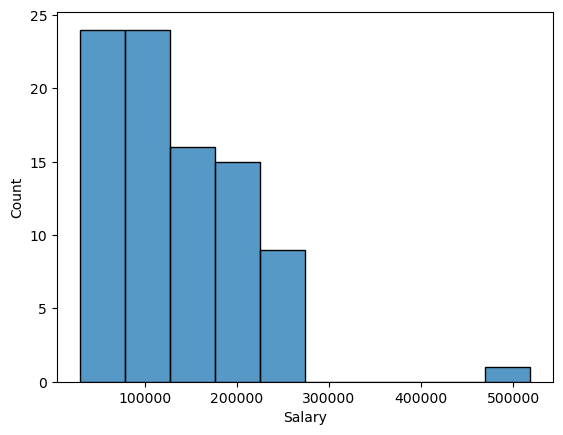

In [9]:
for i in df.columns:
    sns.histplot(df[i])
    plt.show()

2.2 Menampilkan Boxplot untuk Menampilkan Sebaran Outlier

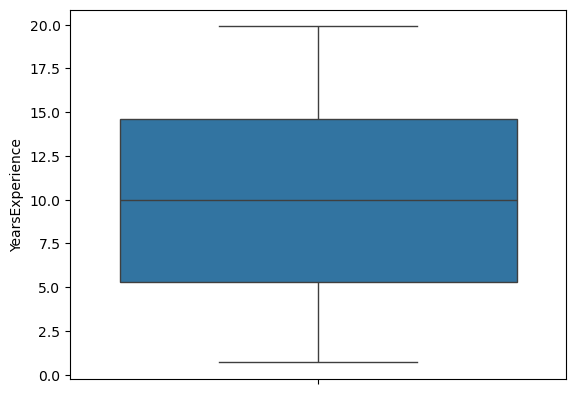

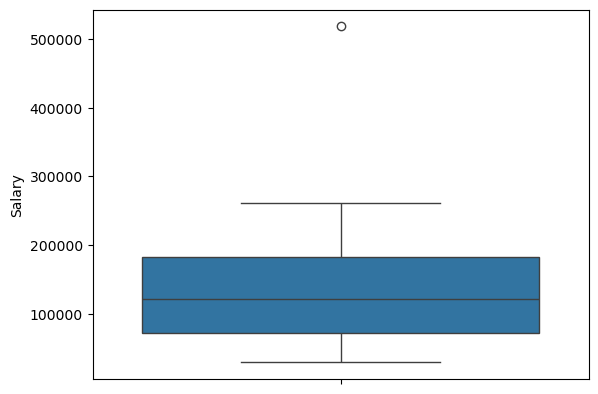

In [10]:
for i in df.columns: 
    sns.boxplot(df[i])
    plt.show()

2.3 Menampilkan Pairplot

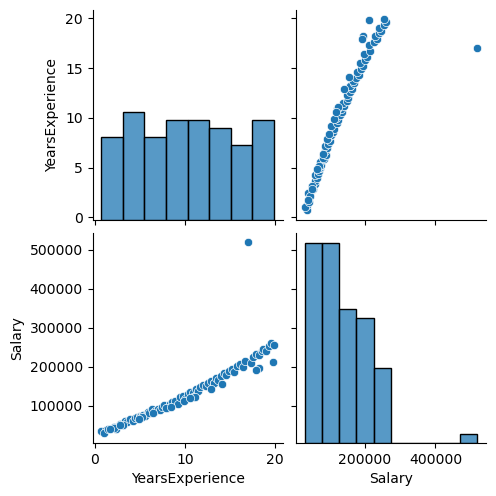

In [11]:
sns.pairplot(df)

2.4 Menampilkan Heatmap untuk melihat Korelasi Data

<Axes: >

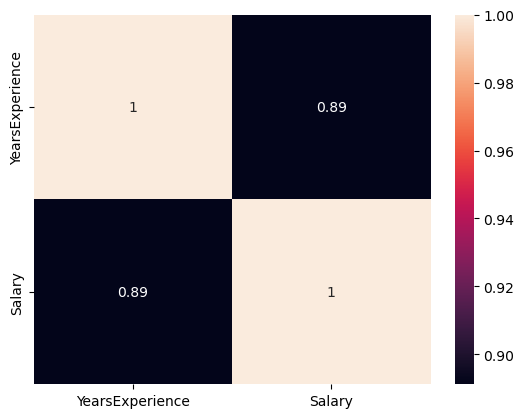

In [12]:
sns.heatmap(df.corr(), annot=True)

3. DATA PREPROCESSING

3.1 Menangani Data Kosong

In [13]:
df = df.dropna()

3.2 Menangani Duplikasi Data

In [14]:
df = df.drop_duplicates()

3.3 Menangani Outlier 

In [15]:
df = df[~((df['YearsExperience'] > 15) & (df['Salary'] > 400000))]

3.4 Menampikan Pairplot Data setelah Proses Data Reprocessing

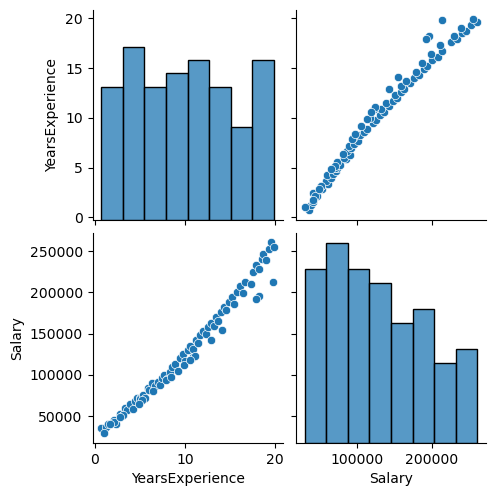

In [16]:
sns.pairplot(df)

4. PEMODELAN

4.1 Splitting Data

In [17]:
df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

4.2 Feature Sellection Feature Scalling

In [18]:
x_train = df_train['YearsExperience']
y_train = df_train['Salary']
x_train_std = x_train.std()
x_tr_stdz = (x_train - x_train.mean()) / x_train_std

x_test = df['YearsExperience']

x_te_stdz = (x_test - x_train.mean()) / x_train_std
y_test = df['Salary']

4.3 Menampilkan hasil Standarisasi

In [19]:
x_tr_stdz.describe()

count   68.0000
mean     0.0000
std      1.0000
min     -1.7205
25%     -0.8643
50%      0.0107
75%      0.7266
max      1.8730
Name: YearsExperience, dtype: float64

In [20]:
x_te_stdz.describe()

count   85.0000
mean     0.0203
std      1.0419
min     -1.7205
25%     -0.8783
50%      0.0014
75%      0.8249
max      1.8730
Name: YearsExperience, dtype: float64

4.4 Model Simple Linear Regression

In [21]:
class linearRegression:
    def __init__(self):
        self.m = None
        self.b = None
 
    def fit(self, x, y):
        self.m = (len(x) * np.sum(x * y) - np.sum(x) * np.sum(y)) / (len(x) * np.sum(x**2) - np.sum(x)**2)
 
        self.b = (np.sum(y) - self.m * np.sum(x)) / len(x)
 
    def predict(self, x):
        y = self.m * x + self.b
        return y


In [22]:
model = linearRegression()
model.fit(x_tr_stdz, y_train)

In [23]:
y_pred_train = model.predict(x_tr_stdz)
y_pred_test = model.predict(x_te_stdz)

5. EVALUASI

5.1 Fungsi Evaluasi

In [24]:
def eval(y, y_pred):
    r_squared = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    mse = np.mean((y- y_pred)**2)
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(mse)
    print(f'Root Squared : {r_squared * 100:.2f}%')
    print(f'MSE : {mse}')
    print(f'MAE :{mae}')
    print(f'RMSE :{rmse}')


5.2 Evaluasi Data Train

In [25]:
eval(y_train, y_pred_train)

Root Squared : 97.59%
MSE : 92102589.37550703
MAE :7236.49920598908
RMSE :9597.009397489774


5.3 Evaluasi Data Test

In [26]:
eval (y_test, y_pred_test)

Root Squared : 97.60%
MSE : 97620514.78692636
MAE :7403.300733652608
RMSE :9880.30944793362


5.4 Menampilkan Grafik Prediksi menggunakan Data Test

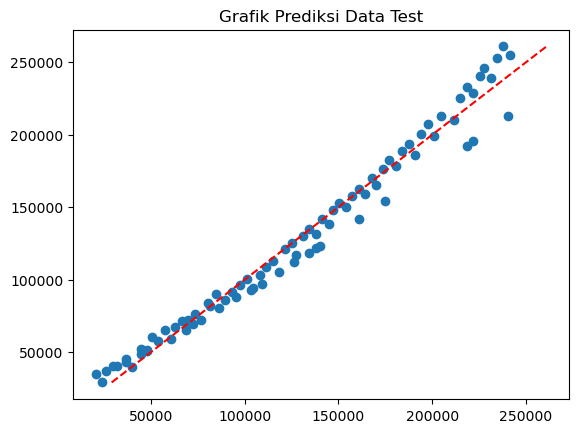

In [27]:
plt.scatter(y_pred_test, y_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Grafik Prediksi Data Test')
plt.show()


5.5 Menampilkan Grafik Prediksi menggunakan Data Train

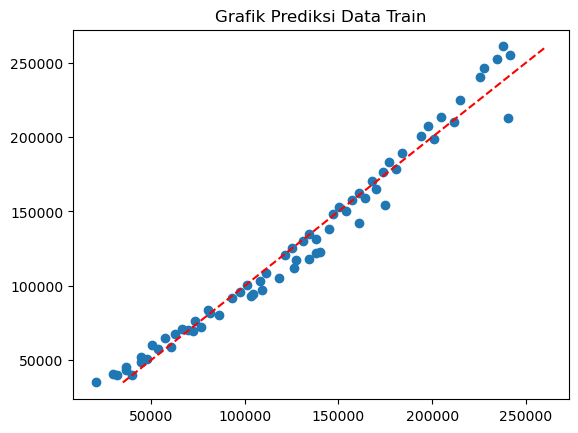

In [28]:
plt.scatter(y_pred_train, y_train)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r')
plt.title('Grafik Prediksi Data Train')
plt.show()


6. GUI (Graphical User Interface)

In [29]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd


In [30]:
def submit():
    try:
        year = float(entry_year.get())
    except ValueError:
        messagebox.showerror("ERROR", 'Please Input By Number')
        return
 
    x_baru = pd.DataFrame({'YearsExperience': [year]})
    x_std = (x_baru - x_train.mean()) / x_train_std
    y_pred_baru = model.predict(x_std).values
    gaji = float(y_pred_baru[0])
    gaji_per_bulan_idr = (gaji * 17000) / 12
    result_label.config(text=f"Rp {gaji_per_bulan_idr:,.0f} /tahun".replace(",", "."))


In [31]:
window = tk.Tk()
window.title("Salary Prediction App")
window.geometry('450x550')
window.configure(bg='#F0F4F8')  
window.resizable(False, False)
 
style = ttk.Style()
style.theme_use('clam')


In [32]:
header_label = tk.Label(
    window, 
    text="Salary Predictor", 
    font=('Segoe UI', 20, 'bold'), 
    bg='#F0F4F8', 
    fg='#1E293B'
)
header_label.pack(pady=(30, 5))
 
sub_header = tk.Label(
    window, 
    text="Prediksi gaji berdasarkan pengalaman kerja", 
    font=('Segoe UI', 10), 
    bg='#F0F4F8', 
    fg='#64748B'
)
sub_header.pack(pady=(0, 20))


In [ ]:
card = tk.Frame(window, bg='#FFFFFF', bd=0, highlightthickness=1, highlightbackground='#E2E8F0')
card.pack(padx=30, pady=10, fill='both', expand=True)
 
input_label = tk.Label(
    card, 
    text="Pengalaman Kerja (Tahun)", 
    font=('Segoe UI', 11, 'bold'), 
    bg='#FFFFFF', 
    fg='#334155'
)
input_label.pack(anchor='w', padx=25, pady=(25, 5))
 
entry_year = tk.Entry(
    card, 
    font=('Segoe UI', 12), 
    bg='#F8FAFC', 
    fg='#0F172A', 
    bd=1, 
    relief='solid',
    justify='center'
)
entry_year.pack(fill='x', padx=25, ipady=8)
 
btn_predict = tk.Button(
    card, 
    text="Hitung Prediksi", 
    font=('Segoe UI', 11, 'bold'), 
    bg='#2563EB', 
    fg='white', 
    activebackground='#1D4ED8', 
    activeforeground='white',
    bd=0, 
    cursor='hand2',
    command=submit
)
btn_predict.pack(fill='x', padx=25, pady=20, ipady=8)


In [34]:
result_title = tk.Label(
    card, 
    text="Estimasi Gaji Ditawarkan:", 
    font=('Segoe UI', 9), 
    bg='#FFFFFF', 
    fg='#64748B'
)
result_title.pack(pady=(10, 0))
 
result_label = tk.Label(
    card, 
    text="Rp 0", 
    font=('Segoe UI', 16, 'bold'), 
    bg='#FFFFFF', 
    fg='#0F172A'
)
result_label.pack(pady=(0, 25))


In [ ]:
window.mainloop()

/var/folders/8v/_f429jcx7lv2yx9w891n346h0000gn/T/ipykernel_6063/1999307493.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gaji = float(y_pred_baru[0])
